# Separation plot: composed vs. not, colored by `optimal_value_avg`

Same tree logic as `select_composed_neurons.py`, shown visually:

- **background** = the tree's predicted `optimal_value_avg`, over the 2 most important features (a smooth map of "the separation")
- **dashed line** = the "composed" cutoff (same z-score rule as `select_composed_neurons.py`)
- **dots** = the actual neuron pairs, colored by their **true** `optimal_value_avg`

Edit `CSV_PATH` in the config cell below to point at your results file, then Run All.

In [5]:
%matplotlib inline

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from sklearn.tree import DecisionTreeRegressor

## Config

In [7]:
CSV_PATH = "combo_summary.csv"
TARGET_COL = "optimal_value_avg"
FEATURE_COLS = ["l", "u_idx", "k", "j_idx", "LB_neuron1", "UB_neuron1", "LB_neuron2", "UB_neuron2"]
STRATEGY_FILTER = "composed"   # set to None to use every row regardless of strategy
MAX_DEPTH = 4
MIN_LEAF = 3
Z_THRESH = 1.0                  # same "largely superior" cutoff as select_composed_neurons.py

## Load data and rank features

In [8]:
df = pd.read_csv(CSV_PATH)
if STRATEGY_FILTER is not None and "strategy" in df.columns:
    df = df[df["strategy"] == STRATEGY_FILTER].reset_index(drop=True)
print(f"{len(df)} rows after filtering")

X_full = df[FEATURE_COLS].fillna(-1)
y = df[TARGET_COL]

full_tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF, random_state=42)
full_tree.fit(X_full, y)

importances = pd.Series(full_tree.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances

130 rows after filtering


UB_neuron2    0.605010
u_idx         0.387878
LB_neuron1    0.004149
UB_neuron1    0.001597
LB_neuron2    0.001366
j_idx         0.000000
l             0.000000
k             0.000000
dtype: float64

## Fit a clean 2D tree on the top-2 features, for the boundary

In [9]:
feat_x, feat_y = importances.index[0], importances.index[1]
print(f"Plotting on: x = {feat_x}, y = {feat_y}")

X2 = df[[feat_x, feat_y]].fillna(-1)
viz_tree = DecisionTreeRegressor(max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF, random_state=42)
viz_tree.fit(X2, y)

pad_x = 0.05 * ((X2[feat_x].max() - X2[feat_x].min()) or 1)
pad_y = 0.05 * ((X2[feat_y].max() - X2[feat_y].min()) or 1)
xx, yy = np.meshgrid(
    np.linspace(X2[feat_x].min() - pad_x, X2[feat_x].max() + pad_x, 300),
    np.linspace(X2[feat_y].min() - pad_y, X2[feat_y].max() + pad_y, 300),
)
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[feat_x, feat_y])
grid_pred = viz_tree.predict(grid_df).reshape(xx.shape)

cand_pred = viz_tree.predict(X2)
composed_cutoff = cand_pred.mean() + Z_THRESH * cand_pred.std()
print(f"composed cutoff: {composed_cutoff:.4f}")

Plotting on: x = UB_neuron2, y = u_idx
composed cutoff: -3.1503


## Plot: separation + points colored by `optimal_value_avg`

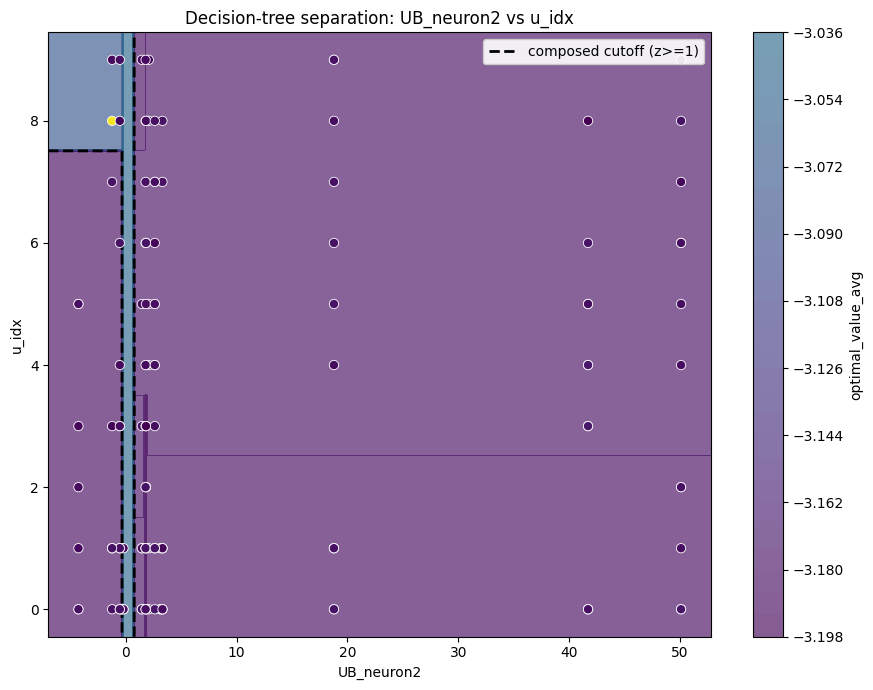

: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
norm = Normalize(vmin=min(y.min(), grid_pred.min()), vmax=max(y.max(), grid_pred.max()))
cmap = plt.cm.viridis

background = ax.contourf(xx, yy, grid_pred, levels=30, cmap=cmap, norm=norm, alpha=0.65)
ax.contour(xx, yy, grid_pred, levels=[composed_cutoff], colors="black", linewidths=2, linestyles="--")
ax.scatter(df[feat_x], df[feat_y], c=y, cmap=cmap, norm=norm,
           edgecolors="white", linewidths=0.6, s=45, zorder=3)

cbar = fig.colorbar(background, ax=ax)
cbar.set_label(TARGET_COL)
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_title(f"Decision-tree separation: {feat_x} vs {feat_y}")

proxy = Line2D([0], [0], color="black", linewidth=2, linestyle="--",
               label=f"composed cutoff (z>={Z_THRESH:g})")
ax.legend(handles=[proxy], loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.savefig("separation_plot.png", dpi=150, bbox_inches="tight")
plt.show()